In [1]:
import numpy as np
import networkx as nx
import itertools as it
import random as rd
import pickle as pk
import pandas as pd
from collections import (defaultdict,Counter)
import matplotlib.pyplot as plt
import scipy  
from scipy import stats


In [2]:
def overlap_jaccard(list1,list2):
    intersction_term= len(set(list1) & set(list2))
    denominator = len(set(list1).union(set(list2)))
    overlap_jaccard_coeff = intersction_term/denominator
    return overlap_jaccard_coeff

def overlap_genelists(lstA, lstB, background):
    import scipy.stats as stats
    """
    Accepts to lists
    M is the population size (previously N)
    n is the number of successes in the population
    N is the sample size (previously n)
    x is still the number of drawn “successes”
    """
    setA= set(lstA)
    setB= set(lstB)
    M= background #total number of genes
    n= len(setA)
    N= len(setB)
    x= len(setA.intersection(setB))


    return str(stats.hypergeom.sf(x-1, M, n, N))

#Here we define the adjustment
from statsmodels.sandbox.stats.multicomp import multipletests
def fdr_adjustment(list_of_pvals,alpha):    
    return multipletests(list_of_pvals,alpha=alpha,method='fdr_bh')[1] #the benjamin hochberg method is used

In [6]:
#Let's import the PPIs
ppi = pd.read_csv("input/autocore_ppi_symbol_lcc.csv",delimiter= ',',
           skipinitialspace=True)
G_ppi = nx.from_pandas_edgelist(ppi, 'symbol1', 'symbol2')

string_ppi = pd.read_csv("input/9606.protein.links.detailed.v12.0.txt",delimiter= ' ')

In [11]:
string_protein_info = pd.read_csv("input/9606.protein.info.v12.0.txt",delimiter= '\t')

In [12]:
#Create a dictionary between the string id and the gene name
string_protein_inf = string_protein_info[["#string_protein_id","preferred_name"]]
string_protein_info_dict = dict(zip(string_protein_inf["#string_protein_id"],string_protein_inf["preferred_name"]))


In [13]:
string_ppi_high_confidence_tot = string_ppi[string_ppi["combined_score"]>700]
string_ppi_high_confidence_experimental = string_ppi[(string_ppi["combined_score"]>700) & (string_ppi["experimental"]>0)]
string_ppi_high_confidence_coexpression = string_ppi[(string_ppi["combined_score"]>700) & (string_ppi["coexpression"]>0)]
string_ppi_high_confidence_textmining = string_ppi[(string_ppi["combined_score"]>700) & (string_ppi["textmining"]>0)]
G_string_ppi_tot = nx.from_pandas_edgelist(string_ppi_high_confidence_tot, 'protein1', 'protein2')
G_string_ppi_exp = nx.from_pandas_edgelist(string_ppi_high_confidence_experimental, 'protein1', 'protein2')
G_string_ppi_coexpression = nx.from_pandas_edgelist(string_ppi_high_confidence_coexpression, 'protein1', 'protein2')
G_string_ppi_tm = nx.from_pandas_edgelist(string_ppi_high_confidence_textmining, 'protein1', 'protein2')

#Relable each node based on the string_protein_info_dict dictionary
G_string_ppi_tot_symbol = nx.relabel_nodes(G_string_ppi_tot, string_protein_info_dict)
G_string_ppi_exp_symbol = nx.relabel_nodes(G_string_ppi_exp, string_protein_info_dict)
G_string_ppi_coexpression_symbol = nx.relabel_nodes(G_string_ppi_coexpression, string_protein_info_dict)
G_string_ppi_tm_symbol = nx.relabel_nodes(G_string_ppi_tm, string_protein_info_dict)



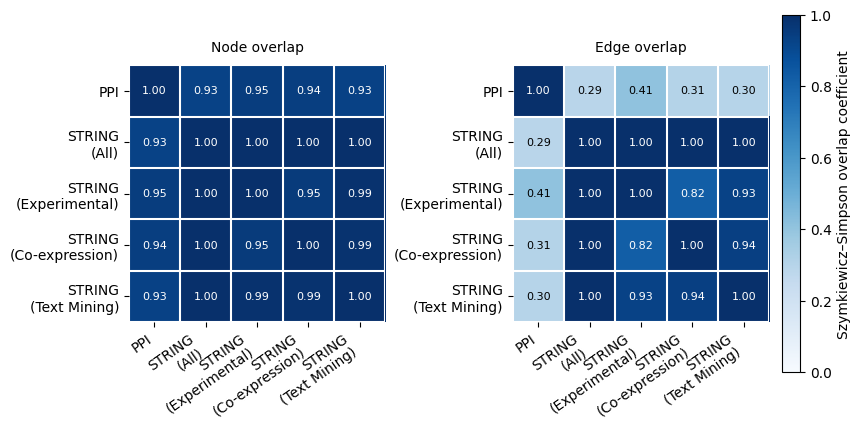

In [20]:

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize

networks = {
    "PPI": G_ppi,
    "STRING\n(All)": G_string_ppi_tot_symbol,
    "STRING\n(Experimental)": G_string_ppi_exp_symbol,
    "STRING\n(Co-expression)": G_string_ppi_coexpression_symbol,
    "STRING\n(Text Mining)": G_string_ppi_tm_symbol,
}

node_sets = {
    name: set(G.nodes())
    for name, G in networks.items()
}

edge_sets = {}

for name, G in networks.items():
    edge_sets[name] = {
        frozenset((u, v))
        for u, v in G.edges()
        if u != v
    }

#Because network densities are very different across networks, we cannot just use Jaccard Index
def overlap_coefficient(a, b):
    """
    Szymkiewicz–Simpson overlap coefficient.

    Returns
    -------
    |A ∩ B| / min(|A|, |B|)

    Values:
        1.0 : the smaller set is entirely contained in the larger
        0.0 : no overlap
    """
    if len(a) == 0 or len(b) == 0:
        return np.nan

    return len(a & b) / min(len(a), len(b))

names = list(networks.keys())
n = len(names)

node_mat = np.zeros((n, n))
edge_mat = np.zeros((n, n))

for i, ni in enumerate(names):
    for j, nj in enumerate(names):

        node_mat[i, j] = overlap_coefficient(node_sets[ni], node_sets[nj])
        edge_mat[i, j] = overlap_coefficient(edge_sets[ni], edge_sets[nj])

node_df = pd.DataFrame(node_mat, index=names, columns=names)
edge_df = pd.DataFrame(edge_mat, index=names, columns=names)

###############################################################################
# Plot
###############################################################################

fig, axes = plt.subplots(
    1,
    2,
    figsize=(8.5, 4.2),
    constrained_layout=True
)

cmap = plt.cm.Blues
norm = Normalize(vmin=0, vmax=1)

for ax, data, title in zip(
    axes,
    [node_df, edge_df],
    ["Node overlap", "Edge overlap"]
):

    im = ax.imshow(
        data.values,
        cmap=cmap,
        norm=norm,
        interpolation="nearest",
    )

    ax.set_xticks(range(n))
    ax.set_xticklabels(names, rotation=35, ha="right")

    ax.set_yticks(range(n))
    ax.set_yticklabels(names)

    ax.set_title(title, fontsize=10, pad=10)

    ax.set_aspect("equal")

    for i in range(n):
        for j in range(n):
            value = data.iloc[i, j]

            ax.text(
                j,
                i,
                f"{value:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color="black" if value < 0.65 else "white",
            )

    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)

    ax.grid(which="minor",
            color="white",
            linewidth=1.5)

    ax.tick_params(which="minor", bottom=False, left=False)

###############################################################################
# Shared colorbar
###############################################################################

cbar = fig.colorbar(
    im,
    ax=axes,
    fraction=0.045,
    pad=0.02,
)

cbar.set_label("Szymkiewicz–Simpson overlap coefficient")

###############################################################################
# Save
###############################################################################

plt.savefig(
    "Figures/Network_overlap_heatmaps_GenEpi.pdf",
    bbox_inches="tight",
)

plt.savefig(
    "Figures/Network_overlap_heatmaps_GenEpi.svg",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

In [19]:
for name in networks:

    print(f"\n{name}")
    print(f"Nodes : {len(node_sets[name]):,}")
    print(f"Edges : {len(edge_sets[name]):,}")


PPI
Nodes : 18,816
Edges : 478,353

STRING
(All)
Nodes : 16,185
Edges : 236,000

STRING
(Experimental)
Nodes : 13,878
Edges : 157,274

STRING
(Co-expression)
Nodes : 14,963
Edges : 186,113

STRING
(Text Mining)
Nodes : 15,905
Edges : 220,542


In [21]:

def net_modularity(genelist,network):
    geneset=set(genelist)&network.nodes()
    if len(geneset)>2:
        G_sub = nx.subgraph(network,geneset)
        Gsub_lcc = G_sub.subgraph(max(nx.connected_components(G_sub), key=len))  # extract lcc graph
        number_of_connected_component=Gsub_lcc.number_of_nodes()
        f_lcc_size = Gsub_lcc.number_of_nodes()
        l_random_lccs = []
        S = 1000
        for s in range(S):
            gene_sample = rd.sample(list(network.nodes()),len(geneset))
            G_sub_rnd = nx.subgraph(network,gene_sample)
            G_sub_rnd_lcc = G_sub_rnd.subgraph(max(nx.connected_components(G_sub_rnd), key=len))  # extract lcc graph
            lcc_size = G_sub_rnd_lcc.number_of_nodes()
            l_random_lccs.append(lcc_size)
        mu = np.mean(l_random_lccs)
        std = np.std(l_random_lccs)
        z = (f_lcc_size-mu)/std
    else:
        number_of_connected_component=0
        z='nan'
    return z

In [22]:
#Let's import the GDA
with open('output/allsources_icd_gene_dict_unified_v2026_official.pickle', 'rb') as handle:
    allsources_icd_gene_dict_unified = pk.load(handle)

In [23]:
string_allsources_icd_gene_dict_unified_lcczscore = {}
for net_name,net in networks.items():
    if "STRING" in net_name:
        allsources_icd_gene_dict_unified_lcczscore = {}
        for dis,genelist in allsources_icd_gene_dict_unified.items():
            lcc_z = net_modularity(genelist,net)
            allsources_icd_gene_dict_unified_lcczscore[dis] = lcc_z
        string_allsources_icd_gene_dict_unified_lcczscore[net_name] = allsources_icd_gene_dict_unified_lcczscore


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_58820/878989659.py:18: RuntimeWarning: invalid value encountered in scalar divide
  z = (f_lcc_size-mu)/std


In [26]:
#let's import the original lcc
with open('output/allsources_icd_gene_dict_unified_lcczscore_v2026_official.pickle', 'rb') as handle:
    ppi_allsources_icd_gene_dict_unified_lcczscore = pk.load(handle)

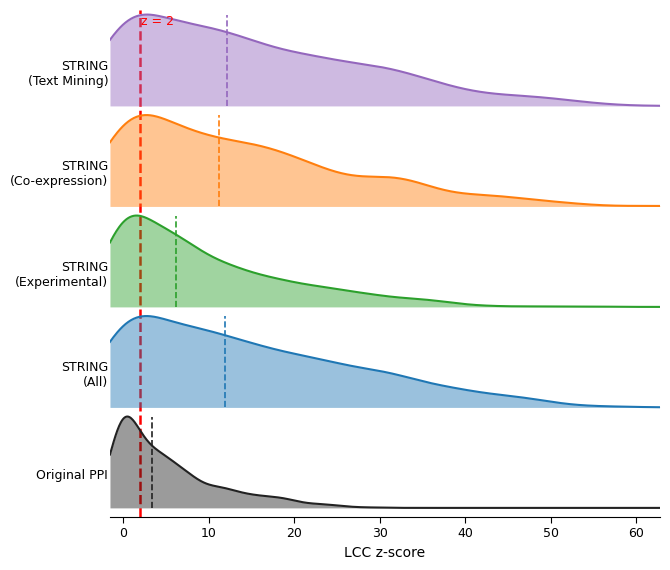

In [27]:

from scipy.stats import gaussian_kde

datasets = {
    "Original PPI": ppi_allsources_icd_gene_dict_unified_lcczscore,
    **string_allsources_icd_gene_dict_unified_lcczscore
}

data = {}

for name, d in datasets.items():
    vals = np.asarray(list(d.values()), dtype=float)
    vals = vals[np.isfinite(vals)]
    data[name] = vals

xmin = min(v.min() for v in data.values())
xmax = max(v.max() for v in data.values())

pad = 0.5
x = np.linspace(xmin-pad, xmax+pad, 600)

###############################################################################
# Plot
###############################################################################

fig, ax = plt.subplots(figsize=(6.8, 5.8))

offset = 0.0
spacing = 1.1

colors = [
    "#222222",
    "#1f77b4",
    "#2ca02c",
    "#ff7f0e",
    "#9467bd"
]

for color, (name, values) in zip(colors, data.items()):

    kde = gaussian_kde(values, bw_method='scott')
    y = kde(x)
    y /= y.max()                 # normalize height

    ax.fill_between(
        x,
        offset,
        offset + y,
        color=color,
        alpha=0.45,
        linewidth=0,
    )

    ax.plot(
        x,
        offset + y,
        color=color,
        lw=1.5
    )

    median = np.median(values)

    ax.vlines(
        median,
        offset,
        offset + 1,
        color=color,
        lw=1.2,
        ls="--"
    )

    ax.text(
        xmin-pad-0.2,
        offset+0.35,
        name,
        ha="right",
        va="center",
        fontsize=9
    )

    offset += spacing

ax.axvline(
    2,
    color="red",
    lw=1.8,
    ls="--",
    zorder=0
)

ax.text(
    2.03,
    offset-0.1,
    "z = 2",
    color="red",
    fontsize=9,
    va="top"
)

ax.set_xlim(xmin-pad, xmax+pad)

ax.set_ylim(-0.1, offset-0.05)

ax.set_xlabel("LCC z-score", fontsize=10)
ax.set_ylabel("")

ax.set_yticks([])

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.tick_params(
    axis='x',
    width=0.8,
    length=4,
    labelsize=9
)

###############################################################################
# Save
###############################################################################

plt.tight_layout()

plt.savefig(
    "Figures/LCC_zscore_distributions_strings.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Figures/LCC_zscore_distributions_strings.svg",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [32]:
for k,v in data.items():
    print(k,len(v),np.median(v),len(v[v>2]))

Original PPI 637 3.3192384577953717 374
STRING
(All) 628 11.910379626911267 502
STRING
(Experimental) 618 6.135779530931589 441
STRING
(Co-expression) 618 11.175920601916255 492
STRING
(Text Mining) 628 12.176735578015272 502


In [33]:
#Let's import the partitions
with open('output/G_gene_icd_ICD_partition_v2026_official.pickle', 'rb') as handle:
    G_gene_icd_ICD_partition = pk.load(handle)

with open('output/G_gene_icd_com_v2026_official.pickle', 'rb') as handle:
    G_gene_icd_com = pk.load(handle)

    

In [34]:
louvain_cat_genedict = {}
for com_louvain,dislist in G_gene_icd_com.items():
    genelist = []
    for dis in dislist:
        genelist.extend(list(allsources_icd_gene_dict_unified[dis]))
    louvain_cat_genedict[com_louvain] = set(genelist)
        

In [35]:
icd_cat_genedict = {}
for icd_cat,dis_list in G_gene_icd_ICD_partition.items():
    genelist = []
    for dis in dis_list:
        genelist.extend(list(allsources_icd_gene_dict_unified[dis]))
    icd_cat_genedict[icd_cat] = list(set(genelist))

In [36]:
string_icd_cat_genedict_lcc_dict = {}
for net_name,net in networks.items():
    icd_cat_genedict_lcc_dict = {}
    for icd_cat,geneset in icd_cat_genedict.items():
        lcc_z = net_modularity(geneset,net)
        icd_cat_genedict_lcc_dict[icd_cat] = lcc_z
    string_icd_cat_genedict_lcc_dict[net_name] = icd_cat_genedict_lcc_dict

string_louvain_cat_genedict_lcc_dict = {}
for net_name,net in networks.items():
    louvain_cat_genedict_lcc_dict = {}
    for louvain_cat,geneset in louvain_cat_genedict.items():
        lcc_z = net_modularity(geneset,net)
        louvain_cat_genedict_lcc_dict[louvain_cat] = lcc_z
    string_louvain_cat_genedict_lcc_dict[net_name] = louvain_cat_genedict_lcc_dict


In [44]:
#Let's compute the ratio of the median grouped lcc z-score vs all diseases for all networks

string_icd_cat_genedict_lcc_ratio_dict = {}
for net_name,z_score_dict in string_icd_cat_genedict_lcc_dict.items():
    if "STRING" in net_name:
        median_all = np.median([el for el in list(string_allsources_icd_gene_dict_unified_lcczscore[net_name].values()) if str(el) != 'nan'])
        median_grouped = np.median([el for el in list(z_score_dict.values()) if str(el) != 'nan'])
        ratio = median_grouped/median_all
        string_icd_cat_genedict_lcc_ratio_dict[net_name] = ratio
    else:
        median_all = np.median([el for el in list(ppi_allsources_icd_gene_dict_unified_lcczscore.values()) if str(el) != 'nan'])
        median_grouped = np.median(list(z_score_dict.values()))
        ratio = median_grouped/median_all
        string_icd_cat_genedict_lcc_ratio_dict[net_name] = ratio

string_louvain_cat_genedict_lcc_ratio_dict = {}
for net_name,z_score_dict in string_louvain_cat_genedict_lcc_dict.items():
    if "STRING" in net_name:
        median_all = np.median([el for el in list(string_allsources_icd_gene_dict_unified_lcczscore[net_name].values()) if str(el) != 'nan'])
        median_grouped = np.median(list(z_score_dict.values()))
        ratio = median_grouped/median_all
        string_louvain_cat_genedict_lcc_ratio_dict[net_name] = ratio
    else:
        median_all = np.median([el for el in list(ppi_allsources_icd_gene_dict_unified_lcczscore.values()) if str(el) != 'nan'])
        median_grouped = np.median(list(z_score_dict.values()))
        ratio = median_grouped/median_all
        string_louvain_cat_genedict_lcc_ratio_dict[net_name] = ratio


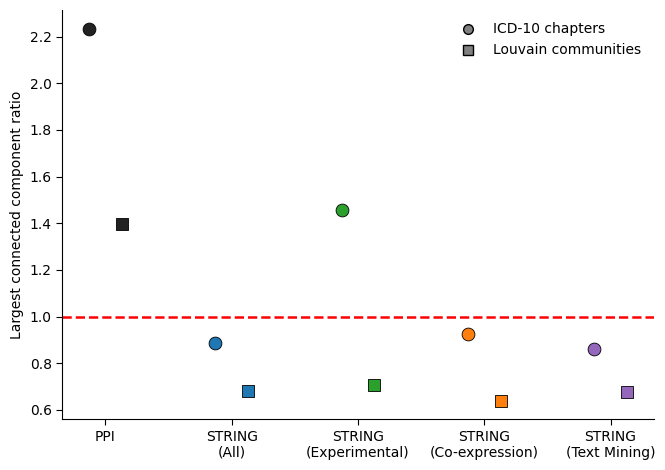

In [53]:

colors = [
    "#222222",
    "#1f77b4",
    "#2ca02c",
    "#ff7f0e",
    "#9467bd",
]

network_order = [
    "PPI",
    "STRING\n(All)",
    "STRING\n(Experimental)",
    "STRING\n(Co-expression)",
    "STRING\n(Text Mining)",
]

disease_values = [
    string_icd_cat_genedict_lcc_ratio_dict["PPI"],
    string_icd_cat_genedict_lcc_ratio_dict["STRING\n(All)"],
    string_icd_cat_genedict_lcc_ratio_dict["STRING\n(Experimental)"],
    string_icd_cat_genedict_lcc_ratio_dict["STRING\n(Co-expression)"],
    string_icd_cat_genedict_lcc_ratio_dict["STRING\n(Text Mining)"],
]

louvain_values = [
    string_louvain_cat_genedict_lcc_ratio_dict["PPI"],
    string_louvain_cat_genedict_lcc_ratio_dict["STRING\n(All)"],
    string_louvain_cat_genedict_lcc_ratio_dict["STRING\n(Experimental)"],
    string_louvain_cat_genedict_lcc_ratio_dict["STRING\n(Co-expression)"],
    string_louvain_cat_genedict_lcc_ratio_dict["STRING\n(Text Mining)"],
]

###############################################################################
# Plot
###############################################################################

fig, ax = plt.subplots(figsize=(6.8,4.8))

x = np.arange(len(network_order))

offset = 0.13

for i, c in enumerate(colors):

    # disease modules
    ax.scatter(
        x[i]-offset,
        disease_values[i],
        s=85,
        color=c,
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )

    # louvain modules
    ax.scatter(
        x[i]+offset,
        louvain_values[i],
        s=85,
        color=c,
        marker="s",
        edgecolor="black",
        linewidth=0.6,
        zorder=3
    )

#Horizontal line at y=1

ax.axhline(
1,
color="red",
lw=1.8,
ls="--",
zorder=0
)

ax.set_xticks(x)
ax.set_xticklabels(network_order)

ax.set_ylabel("Largest connected component ratio")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis='both',
    length=4,
    width=0.8
)

disease_proxy = plt.Line2D(
    [0], [0],
    marker='o',
    linestyle='',
    color='white',
    markerfacecolor='gray',
    markeredgecolor='black',
    markersize=7,
    label='ICD-10 chapters'
)

louvain_proxy = plt.Line2D(
    [0], [0],
    marker='s',
    linestyle='',
    color='white',
    markerfacecolor='gray',
    markeredgecolor='black',
    markersize=7,
    label='Louvain communities'
)

ax.legend(
    handles=[disease_proxy, louvain_proxy],
    frameon=False,
    loc='best'
)

plt.tight_layout()

plt.savefig(
    "LCC_ratio_comparison_string.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "LCC_ratio_comparison_string.svg",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [54]:
#Let's calculate the same ratio with diseases belonging to epidemiological trajectories

with open('output/female_trajectories_dict_filtered_unique_v2026_official.pickle', 'rb') as handle:
    female_trajectories_dict_filtered_unique = pk.load(handle)


with open('output/male_trajectories_dict_filtered_unique_v2026_official.pickle', 'rb') as handle:
    male_trajectories_dict_filtered_unique = pk.load(handle)

In [59]:
string_male_trajectories_distinct_lcc_zscore_dict = {}
for net_name,net in networks.items():
    agg_trj_lcc_dict = {}
    for agg_trj,dislist in male_trajectories_dict_filtered_unique.items():
        z_score_list=[]
        if "STRING" in net_name:
            for dis in dislist:
                z = string_allsources_icd_gene_dict_unified_lcczscore[net_name][dis]
                if str(z) != 'nan':
                    z_score_list.append(z)
        else:
            for dis in dislist:
                z = ppi_allsources_icd_gene_dict_unified_lcczscore[dis]
                if str(z) != 'nan':
                    z_score_list.append(z)
        agg_trj_lcc_dict[agg_trj] = z_score_list
    string_male_trajectories_distinct_lcc_zscore_dict[net_name] = agg_trj_lcc_dict
 

In [62]:
string_male_trajectories_mean_distinct_lcc_zscore_dict = {}
for net_name,net in networks.items():
    agg_trj_lcc_dict = {}
    for agg_trj,dislist in male_trajectories_dict_filtered_unique.items():
        z_score_list=[]
        if "STRING" in net_name:
            for dis in dislist:
                z = string_allsources_icd_gene_dict_unified_lcczscore[net_name][dis]
                if str(z) != 'nan':
                    z_score_list.append(z)
        else:
            for dis in dislist:
                z = ppi_allsources_icd_gene_dict_unified_lcczscore[dis]
                if str(z) != 'nan':
                    z_score_list.append(z)
        agg_trj_lcc_dict[agg_trj] = np.mean(z_score_list)
    string_male_trajectories_mean_distinct_lcc_zscore_dict[net_name] = agg_trj_lcc_dict

/opt/anaconda3/envs/Epigenetics/lib/python3.10/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/envs/Epigenetics/lib/python3.10/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [60]:
string_male_trajectories_agglomerated_lcc_zscore_dict = {}
for net_name,net in networks.items():
    agg_trj_lcc_dict = {}
    for agg_trj,dislist in male_trajectories_dict_filtered_unique.items():
        tot_genelsit=[]
        for dis in dislist:
            for gene in allsources_icd_gene_dict_unified[dis]:
                if gene not in tot_genelsit:
                    tot_genelsit.append(gene)
        agg_trj_lcc_dict[agg_trj] = net_modularity(tot_genelsit,net)
    string_male_trajectories_agglomerated_lcc_zscore_dict[net_name] = agg_trj_lcc_dict


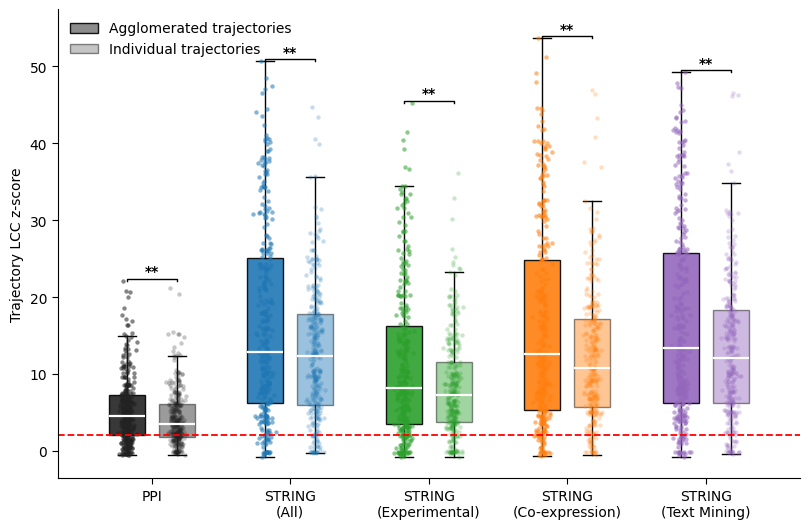

In [65]:
from scipy.stats import mannwhitneyu
colors = [
    "#222222",
    "#1f77b4",
    "#2ca02c",
    "#ff7f0e",
    "#9467bd"
]

network_order = [
    "PPI",
    "STRING\n(All)",
    "STRING\n(Experimental)",
    "STRING\n(Co-expression)",
    "STRING\n(Text Mining)"
]

###############################################################################
# Figure
###############################################################################

fig, ax = plt.subplots(figsize=(8.2,5.4))

offset = 0.18
box_width = 0.26

rng = np.random.default_rng(42)

###############################################################################
# Plot each network
###############################################################################

for i, network in enumerate(network_order):

    ###########################################################################
    # Extract values
    ###########################################################################

    agglomerated = np.asarray(
        list(string_male_trajectories_agglomerated_lcc_zscore_dict[network].values()),
        dtype=float
    )

    distinct = np.asarray(
        list(string_male_trajectories_mean_distinct_lcc_zscore_dict[network].values()),
        dtype=float
    )

    agglomerated = agglomerated[np.isfinite(agglomerated)]
    distinct = distinct[np.isfinite(distinct)]

    ###########################################################################
    # Boxplots
    ###########################################################################

    bp = ax.boxplot(
        [agglomerated, distinct],
        positions=[i-offset, i+offset],
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="white", linewidth=1.6),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
        boxprops=dict(linewidth=1),
    )

    bp["boxes"][0].set_facecolor(colors[i])
    bp["boxes"][1].set_facecolor(colors[i])

    bp["boxes"][0].set_alpha(0.90)
    bp["boxes"][1].set_alpha(0.45)

    ###########################################################################
    # Jittered observations
    ###########################################################################

    jitter1 = rng.normal(i-offset, 0.025, len(agglomerated))
    jitter2 = rng.normal(i+offset, 0.025, len(distinct))

    ax.scatter(
        jitter1,
        agglomerated,
        s=10,
        color=colors[i],
        alpha=0.55,
        linewidth=0,
        zorder=2,
    )

    ax.scatter(
        jitter2,
        distinct,
        s=10,
        color=colors[i],
        alpha=0.25,
        linewidth=0,
        zorder=2,
    )
    ###############################################################################
    # Statistical significance
    ###############################################################################

    stat, p_value = mannwhitneyu(
        agglomerated,
        distinct,
        alternative="two-sided"
    )

    # Significance label
    if p_value < 1e-4:
        sig = "****"
    elif p_value < 1e-3:
        sig = "***"
    elif p_value < 1e-2:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        sig = "ns"

    # Height of the bracket
    y = max(np.max(agglomerated), np.max(distinct))
    h = 0.25

    # Draw bracket
    ax.plot(
        [i-offset, i-offset, i+offset, i+offset],
        [y, y+h, y+h, y],
        color="black",
        lw=1
    )

    # Stars
    ax.text(
        i,
        y+h+0.05,
        sig,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax + 0.8)
###############################################################################
# Significance threshold
###############################################################################

ax.axhline(
    2,
    color="red",
    linestyle="--",
    linewidth=1.3,
)

###############################################################################
# Cosmetics
###############################################################################

ax.set_xticks(range(len(network_order)))
ax.set_xticklabels(network_order)

ax.set_ylabel("Trajectory LCC z-score")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    width=0.8,
    length=4
)

###############################################################################
# Legend
###############################################################################

from matplotlib.patches import Patch

legend = [

    Patch(
        facecolor="gray",
        alpha=0.9,
        edgecolor="black",
        label="Agglomerated trajectories"
    ),

    Patch(
        facecolor="gray",
        alpha=0.45,
        edgecolor="black",
        label="Individual trajectories"
    )

]

ax.legend(
    handles=legend,
    frameon=False,
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "Trajectory_LCC_boxplots_string_male.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Trajectory_LCC_boxplots_string_male.svg",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [66]:
string_female_trajectories_mean_distinct_lcc_zscore_dict = {}
for net_name,net in networks.items():
    agg_trj_lcc_dict = {}
    for agg_trj,dislist in female_trajectories_dict_filtered_unique.items():
        z_score_list=[]
        if "STRING" in net_name:
            for dis in dislist:
                z = string_allsources_icd_gene_dict_unified_lcczscore[net_name][dis]
                if str(z) != 'nan':
                    z_score_list.append(z)
        else:
            for dis in dislist:
                z = ppi_allsources_icd_gene_dict_unified_lcczscore[dis]
                if str(z) != 'nan':
                    z_score_list.append(z)
        agg_trj_lcc_dict[agg_trj] = np.mean(z_score_list)
    string_female_trajectories_mean_distinct_lcc_zscore_dict[net_name] = agg_trj_lcc_dict

In [67]:
string_female_trajectories_agglomerated_lcc_zscore_dict = {}
for net_name,net in networks.items():
    agg_trj_lcc_dict = {}
    for agg_trj,dislist in female_trajectories_dict_filtered_unique.items():
        tot_genelsit=[]
        for dis in dislist:
            for gene in allsources_icd_gene_dict_unified[dis]:
                if gene not in tot_genelsit:
                    tot_genelsit.append(gene)
        agg_trj_lcc_dict[agg_trj] = net_modularity(tot_genelsit,net)
    string_female_trajectories_agglomerated_lcc_zscore_dict[net_name] = agg_trj_lcc_dict


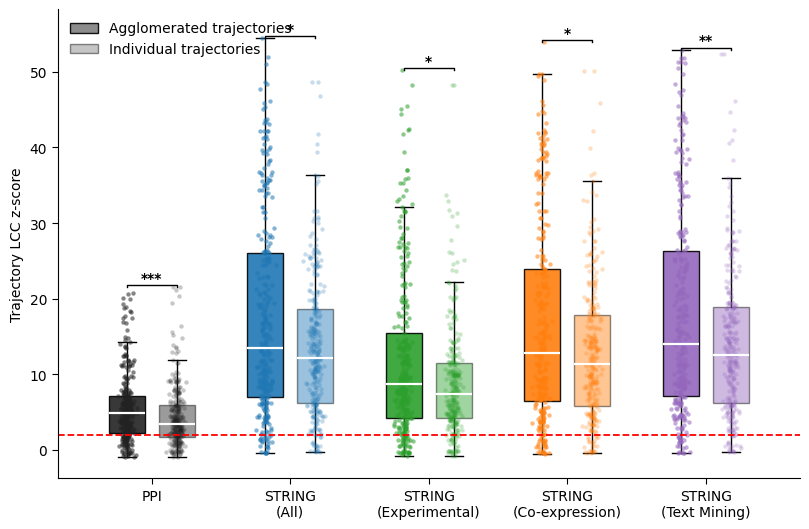

In [68]:
from scipy.stats import mannwhitneyu
colors = [
    "#222222",
    "#1f77b4",
    "#2ca02c",
    "#ff7f0e",
    "#9467bd"
]

network_order = [
    "PPI",
    "STRING\n(All)",
    "STRING\n(Experimental)",
    "STRING\n(Co-expression)",
    "STRING\n(Text Mining)"
]

###############################################################################
# Figure
###############################################################################

fig, ax = plt.subplots(figsize=(8.2,5.4))

offset = 0.18
box_width = 0.26

rng = np.random.default_rng(42)

###############################################################################
# Plot each network
###############################################################################

for i, network in enumerate(network_order):

    ###########################################################################
    # Extract values
    ###########################################################################

    agglomerated = np.asarray(
        list(string_female_trajectories_agglomerated_lcc_zscore_dict[network].values()),
        dtype=float
    )

    distinct = np.asarray(
        list(string_female_trajectories_mean_distinct_lcc_zscore_dict[network].values()),
        dtype=float
    )

    agglomerated = agglomerated[np.isfinite(agglomerated)]
    distinct = distinct[np.isfinite(distinct)]

    ###########################################################################
    # Boxplots
    ###########################################################################

    bp = ax.boxplot(
        [agglomerated, distinct],
        positions=[i-offset, i+offset],
        widths=box_width,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="white", linewidth=1.6),
        whiskerprops=dict(linewidth=1),
        capprops=dict(linewidth=1),
        boxprops=dict(linewidth=1),
    )

    bp["boxes"][0].set_facecolor(colors[i])
    bp["boxes"][1].set_facecolor(colors[i])

    bp["boxes"][0].set_alpha(0.90)
    bp["boxes"][1].set_alpha(0.45)

    ###########################################################################
    # Jittered observations
    ###########################################################################

    jitter1 = rng.normal(i-offset, 0.025, len(agglomerated))
    jitter2 = rng.normal(i+offset, 0.025, len(distinct))

    ax.scatter(
        jitter1,
        agglomerated,
        s=10,
        color=colors[i],
        alpha=0.55,
        linewidth=0,
        zorder=2,
    )

    ax.scatter(
        jitter2,
        distinct,
        s=10,
        color=colors[i],
        alpha=0.25,
        linewidth=0,
        zorder=2,
    )
    ###############################################################################
    # Statistical significance
    ###############################################################################

    stat, p_value = mannwhitneyu(
        agglomerated,
        distinct,
        alternative="two-sided"
    )

    # Significance label
    if p_value < 1e-4:
        sig = "****"
    elif p_value < 1e-3:
        sig = "***"
    elif p_value < 1e-2:
        sig = "**"
    elif p_value < 0.05:
        sig = "*"
    else:
        sig = "ns"

    # Height of the bracket
    y = max(np.max(agglomerated), np.max(distinct))
    h = 0.25

    # Draw bracket
    ax.plot(
        [i-offset, i-offset, i+offset, i+offset],
        [y, y+h, y+h, y],
        color="black",
        lw=1
    )

    # Stars
    ax.text(
        i,
        y+h+0.05,
        sig,
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ymin, ymax = ax.get_ylim()
ax.set_ylim(ymin, ymax + 0.8)
###############################################################################
# Significance threshold
###############################################################################

ax.axhline(
    2,
    color="red",
    linestyle="--",
    linewidth=1.3,
)

###############################################################################
# Cosmetics
###############################################################################

ax.set_xticks(range(len(network_order)))
ax.set_xticklabels(network_order)

ax.set_ylabel("Trajectory LCC z-score")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    width=0.8,
    length=4
)

###############################################################################
# Legend
###############################################################################

from matplotlib.patches import Patch

legend = [

    Patch(
        facecolor="gray",
        alpha=0.9,
        edgecolor="black",
        label="Agglomerated trajectories"
    ),

    Patch(
        facecolor="gray",
        alpha=0.45,
        edgecolor="black",
        label="Individual trajectories"
    )

]

ax.legend(
    handles=legend,
    frameon=False,
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "Trajectory_LCC_boxplots_string_female.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Trajectory_LCC_boxplots_string_female.svg",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [69]:
#Let's import the male trajectories with the evolving diseases
with open('output/male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_v2026_official.pickle', 'rb') as handle:
    male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict = pk.load(handle)

In [70]:
hub_threshold = np.percentile(list(dict(nx.degree(G_ppi)).values()), 90)

trj_hub_dict = {}
for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
    stage_hub_dict = {}
    for stage, dislist in stage_dict.items():
        tot_genelist = []
        for dis in dislist:
            try:
                genelist = list(allsources_icd_gene_dict_unified[dis])
                tot_genelist.extend(genelist)
            except:
                pass
        data = [G_ppi.degree(gene) for gene in tot_genelist]
        hub_count = sum(1 for x in data if x >= hub_threshold)
        # Calculate Proportion
        p = hub_count / len(data) if data else 0
        stage_hub_dict[stage] = p * 100
    trj_hub_dict[trj] = stage_hub_dict

/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_58820/1097108305.py:15: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  hub_count = sum(1 for x in data if x >= hub_threshold)


In [72]:
ascending_trj = []
descending_trj = []
for trj,hub in trj_hub_dict.items():
    gen_max_degree_idx = np.argmax(list(hub.values())) 
    if gen_max_degree_idx !=0:
        ascending_trj.append(trj)
    else:
        descending_trj.append(trj)

print(len(ascending_trj))
print(len(descending_trj))

97
93


In [74]:
networks_ascending_trj_dict = {}
for net_name,net in networks.items():
    hub_threshold = np.percentile(list(dict(nx.degree(net)).values()), 90)

    trj_hub_dict = {}
    for trj,stage_dict in male_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
        stage_hub_dict = {}
        for stage, dislist in stage_dict.items():
            tot_genelist = []
            for dis in dislist:
                try:
                    genelist = list(allsources_icd_gene_dict_unified[dis])
                    tot_genelist.extend(genelist)
                except:
                    pass
            data = [net.degree(gene) for gene in tot_genelist]
            hub_count = sum(1 for x in data if x >= hub_threshold)
            # Calculate Proportion
            p = hub_count / len(data) if data else 0
            stage_hub_dict[stage] = p * 100
        trj_hub_dict[trj] = stage_hub_dict

    trj_classification_dict = {}
    for trj,hub in trj_hub_dict.items():
        gen_max_degree_idx = np.argmax(list(hub.values())) 
        if gen_max_degree_idx !=0:
            trj_classification_dict[trj] = "ascending"
        else:
            trj_classification_dict[trj] = "descending"

    networks_ascending_trj_dict[net_name] = trj_classification_dict


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_58820/21175105.py:17: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  hub_count = sum(1 for x in data if x >= hub_threshold)


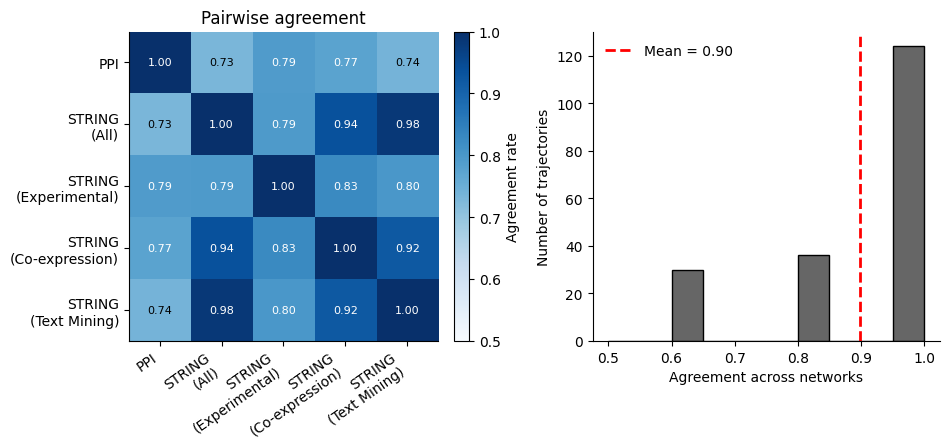

In [77]:

colors = [
    "#222222",
    "#1f77b4",
    "#2ca02c",
    "#ff7f0e",
    "#9467bd"
]

network_order = [
    "PPI",
    "STRING\n(All)",
    "STRING\n(Experimental)",
    "STRING\n(Co-expression)",
    "STRING\n(Text Mining)"
]


agreement = np.zeros((len(network_order), len(network_order)))

for i, net1 in enumerate(network_order):

    dict1 = networks_ascending_trj_dict[net1]

    for j, net2 in enumerate(network_order):

        dict2 = networks_ascending_trj_dict[net2]

        common = sorted(set(dict1) & set(dict2))

        same = sum(
            dict1[t] == dict2[t]
            for t in common
        )

        agreement[i, j] = same / len(common)

agreement_df = pd.DataFrame(
    agreement,
    index=network_order,
    columns=network_order
)

all_trj = sorted(
    set().union(*[
        d.keys()
        for d in networks_ascending_trj_dict.values()
    ])
)

trajectory_agreement = {}

for trj in all_trj:

    labels = []

    for net in network_order:

        if trj in networks_ascending_trj_dict[net]:
            labels.append(
                networks_ascending_trj_dict[net][trj]
            )

    if len(labels) == 0:
        continue

    majority = max(
        labels.count("ascending"),
        labels.count("descending")
    )

    trajectory_agreement[trj] = majority / len(labels)

###############################################################################
# Figure
###############################################################################

fig = plt.figure(figsize=(10,4.5))

gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[1.1,1]
)

###############################################################################
# Heatmap
###############################################################################

ax1 = fig.add_subplot(gs[0])

im = ax1.imshow(
    agreement_df,
    cmap="Blues",
    vmin=0.5,
    vmax=1
)

ax1.set_xticks(range(len(network_order)))
ax1.set_xticklabels(
    network_order,
    rotation=35,
    ha="right"
)

ax1.set_yticks(range(len(network_order)))
ax1.set_yticklabels(network_order)

for i in range(len(network_order)):
    for j in range(len(network_order)):

        ax1.text(
            j,
            i,
            f"{agreement_df.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if agreement_df.iloc[i,j]>0.75 else "black"
        )

ax1.set_title("Pairwise agreement")

cbar = plt.colorbar(
    im,
    ax=ax1,
    fraction=0.045,
    pad=0.04
)

cbar.set_label("Agreement rate")

###############################################################################
# Consensus distribution
###############################################################################

ax2 = fig.add_subplot(gs[1])

agreement_values = list(
    trajectory_agreement.values()
)

bins = np.linspace(0.5,1.0,11)

ax2.hist(
    agreement_values,
    bins=bins,
    color="0.4",
    edgecolor="black"
)

ax2.axvline(
    np.mean(agreement_values),
    color="red",
    lw=2,
    linestyle="--",
    label=f"Mean = {np.mean(agreement_values):.2f}"
)

ax2.set_xlabel("Agreement across networks")
ax2.set_ylabel("Number of trajectories")

ax2.legend(frameon=False)

###############################################################################
# Cosmetics
###############################################################################

for ax in [ax1, ax2]:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "Figures/Trajectory_direction_agreement_male.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Figures/Trajectory_direction_agreement_male.svg",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [78]:
#Let's import the female trajectories with the evolving diseases
with open('output/female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict_v2026_official.pickle', 'rb') as handle:
    female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict = pk.load(handle)
    

In [79]:
networks_ascending_trj_dict = {}
for net_name,net in networks.items():
    hub_threshold = np.percentile(list(dict(nx.degree(net)).values()), 90)
    trj_hub_dict = {}
    for trj,stage_dict in female_trajectories_dis_sort_bytime_grouped_all_add_evolving_dict.items():
        stage_hub_dict = {}
        for stage, dislist in stage_dict.items():
            tot_genelist = []
            for dis in dislist:
                try:
                    genelist = list(allsources_icd_gene_dict_unified[dis])
                    tot_genelist.extend(genelist)
                except:
                    pass
            data = [net.degree(gene) for gene in tot_genelist]
            hub_count = sum(1 for x in data if x >= hub_threshold)
            # Calculate Proportion
            p = hub_count / len(data) if data else 0
            stage_hub_dict[stage] = p * 100
        trj_hub_dict[trj] = stage_hub_dict

    trj_classification_dict = {}
    for trj,hub in trj_hub_dict.items():
        gen_max_degree_idx = np.argmax(list(hub.values())) 
        if gen_max_degree_idx !=0:
            trj_classification_dict[trj] = "ascending"
        else:
            trj_classification_dict[trj] = "descending"

    networks_ascending_trj_dict[net_name] = trj_classification_dict


/var/folders/rm/nxxl_j315bb0tmsp5x9217hh0000gp/T/ipykernel_58820/4189287080.py:16: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  hub_count = sum(1 for x in data if x >= hub_threshold)


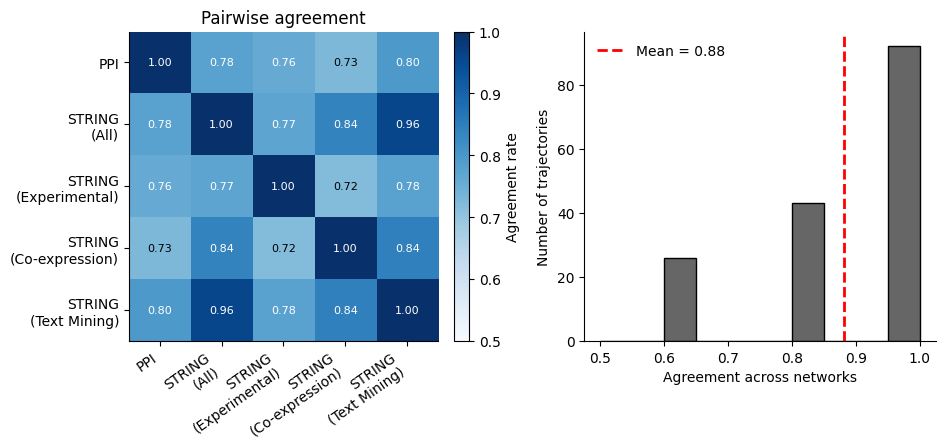

In [80]:

colors = [
    "#222222",
    "#1f77b4",
    "#2ca02c",
    "#ff7f0e",
    "#9467bd"
]

network_order = [
    "PPI",
    "STRING\n(All)",
    "STRING\n(Experimental)",
    "STRING\n(Co-expression)",
    "STRING\n(Text Mining)"
]


agreement = np.zeros((len(network_order), len(network_order)))

for i, net1 in enumerate(network_order):

    dict1 = networks_ascending_trj_dict[net1]

    for j, net2 in enumerate(network_order):

        dict2 = networks_ascending_trj_dict[net2]

        common = sorted(set(dict1) & set(dict2))

        same = sum(
            dict1[t] == dict2[t]
            for t in common
        )

        agreement[i, j] = same / len(common)

agreement_df = pd.DataFrame(
    agreement,
    index=network_order,
    columns=network_order
)

all_trj = sorted(
    set().union(*[
        d.keys()
        for d in networks_ascending_trj_dict.values()
    ])
)

trajectory_agreement = {}

for trj in all_trj:

    labels = []

    for net in network_order:

        if trj in networks_ascending_trj_dict[net]:
            labels.append(
                networks_ascending_trj_dict[net][trj]
            )

    if len(labels) == 0:
        continue

    majority = max(
        labels.count("ascending"),
        labels.count("descending")
    )

    trajectory_agreement[trj] = majority / len(labels)

###############################################################################
# Figure
###############################################################################

fig = plt.figure(figsize=(10,4.5))

gs = fig.add_gridspec(
    1,
    2,
    width_ratios=[1.1,1]
)

###############################################################################
# Heatmap
###############################################################################

ax1 = fig.add_subplot(gs[0])

im = ax1.imshow(
    agreement_df,
    cmap="Blues",
    vmin=0.5,
    vmax=1
)

ax1.set_xticks(range(len(network_order)))
ax1.set_xticklabels(
    network_order,
    rotation=35,
    ha="right"
)

ax1.set_yticks(range(len(network_order)))
ax1.set_yticklabels(network_order)

for i in range(len(network_order)):
    for j in range(len(network_order)):

        ax1.text(
            j,
            i,
            f"{agreement_df.iloc[i,j]:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="white" if agreement_df.iloc[i,j]>0.75 else "black"
        )

ax1.set_title("Pairwise agreement")

cbar = plt.colorbar(
    im,
    ax=ax1,
    fraction=0.045,
    pad=0.04
)

cbar.set_label("Agreement rate")

###############################################################################
# Consensus distribution
###############################################################################

ax2 = fig.add_subplot(gs[1])

agreement_values = list(
    trajectory_agreement.values()
)

bins = np.linspace(0.5,1.0,11)

ax2.hist(
    agreement_values,
    bins=bins,
    color="0.4",
    edgecolor="black"
)

ax2.axvline(
    np.mean(agreement_values),
    color="red",
    lw=2,
    linestyle="--",
    label=f"Mean = {np.mean(agreement_values):.2f}"
)

ax2.set_xlabel("Agreement across networks")
ax2.set_ylabel("Number of trajectories")

ax2.legend(frameon=False)

###############################################################################
# Cosmetics
###############################################################################

for ax in [ax1, ax2]:

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "Figures/Trajectory_direction_agreement_female.pdf",
    bbox_inches="tight"
)

plt.savefig(
    "Figures/Trajectory_direction_agreement_female.svg",
    dpi=600,
    bbox_inches="tight"
)

plt.show()